In [1]:
# %%
import pandas as pd
import numpy as np
import warnings
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

warnings.filterwarnings("ignore")

In [2]:
# 한글 폰트
import matplotlib.pyplot as plt
import warnings

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings("ignore")

In [3]:
# 전처리 설정값
# %%
HIGH_NULL_COLS = [
    "착상 전 유전 검사 사용 여부", "PGD 시술 여부", "PGS 시술 여부",
    "난자 해동 경과일", "배아 해동 경과일",
]
COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]
AGE_MAP = {
    "만18-34세": 26, "만35-37세": 36, "만38-39세": 38,
    "만40-42세": 41, "만43-44세": 43, "만45-50세": 47, "Unknown": 36
}
DONOR_AGE_MAP = {
    "만20세 이하": 19, "만21-25세": 23, "만26-30세": 28,
    "만31-35세": 33, "만36-40세": 38, "만41-45세": 43,
    "알 수 없음": 0, "Unknown": 0
}
CAUSE_COLS = [
    "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
    "불임 원인 - 여성 요인", "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
    "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
]
LOG_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "저장된 배아 수", "수집된 신선 난자 수", "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수", "미세주입 배아 이식 수",
]

label_encoders = {}

In [11]:
# 전처리 함수 
from sklearn.preprocessing import LabelEncoder

def convert_count(val):
    if pd.isna(val) or val == "Unknown":
        return 0
    if "이상" in str(val):
        return 6
    try:
        return int(str(val).replace("회", "").strip())
    except:
        return 0


def preprocess(df, is_train=True):
    df = df.copy()

    # ── ID 처리 ──
    ids = df["ID"].copy() if "ID" in df.columns else None
    df = df.drop(columns=["ID"], errors="ignore")

    # ── 결측 많은 컬럼 제거 ──
    df = df.drop(columns=[c for c in HIGH_NULL_COLS if c in df.columns])

    # ── 날짜 컬럼 처리 ──
    date_cols = ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"]
    for col in date_cols:
        if col in df.columns:
            df[col + "_결측여부"] = df[col].isnull().astype(int)
            df[col] = df[col].fillna(df[col].median() if is_train else 0)

    # ── DI 구조적 결측 처리 ──
    if "시술 유형" in df.columns:
        di_mask = df["시술 유형"] == "DI"

        embryo_cols = [
            "총 생성 배아 수",
            "미세주입에서 생성된 배아 수",
            "저장된 배아 수",
            "미세주입된 난자 수",
            "수집된 신선 난자 수"
        ]

        for col in embryo_cols:
            if col in df.columns:
                df.loc[di_mask, col] = 0
                median_val = df.loc[~di_mask, col].median()
                df.loc[~di_mask, col] = df.loc[~di_mask, col].fillna(median_val)

        df["is_DI"] = (df["시술 유형"] == "DI").astype(int)

    # ── BLASTOCYST feature ──
    if "배아 이식 경과일" in df.columns:
        df["is_blastocyst"] = (df["배아 이식 경과일"] >= 5).astype(int)
        df["is_early_transfer"] = (df["배아 이식 경과일"] <= 3).astype(int)

        def transfer_stage(x):
            if pd.isna(x):
                return "Unknown"
            elif x <= 3:
                return "early"
            elif x <= 4:
                return "mid"
            else:
                return "blast"

        df["배아_이식_stage"] = df["배아 이식 경과일"].apply(transfer_stage)
        df["stage_early"] = (df["배아_이식_stage"] == "early").astype(int)
        df["stage_mid"]   = (df["배아_이식_stage"] == "mid").astype(int)
        df["stage_blast"] = (df["배아_이식_stage"] == "blast").astype(int)

    # ── 숫자형 결측 처리 ──
    num_cols = [c for c in df.select_dtypes(include="number").columns if c != "임신 성공 여부"]
    df[num_cols] = df[num_cols].fillna(0)

    # ── 범주형 결측 처리 ──
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].fillna("Unknown")

    # ── 횟수형 처리 ──
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].apply(convert_count)

    # ── 나이 매핑 ──
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(36)

    for col in ["난자 기증자 나이", "정자 기증자 나이"]:
        if col in df.columns:
            df[col] = df[col].map(DONOR_AGE_MAP).fillna(0)

    # ── IVF / DI 파생 변수 ──
    if "IVF 시술 횟수" in df.columns and "DI 시술 횟수" in df.columns:
        df["IVF_DI_시술_합산"] = df["IVF 시술 횟수"] + df["DI 시술 횟수"]
        df["IVF_시술_비율"] = df["IVF 시술 횟수"] / (df["IVF_DI_시술_합산"] + 1e-6)

    if "IVF 임신 횟수" in df.columns and "DI 임신 횟수" in df.columns:
        df["IVF_DI_임신_합산"] = df["IVF 임신 횟수"] + df["DI 임신 횟수"]
        df["IVF_임신_비율"] = df["IVF 임신 횟수"] / (df["IVF_DI_임신_합산"] + 1e-6)

    if "IVF 출산 횟수" in df.columns and "DI 출산 횟수" in df.columns:
        df["IVF_DI_출산_합산"] = df["IVF 출산 횟수"] + df["DI 출산 횟수"]
        df["IVF_출산_비율"] = df["IVF 출산 횟수"] / (df["IVF_DI_출산_합산"] + 1e-6)

    if "IVF_DI_시술_합산" in df.columns and "IVF_DI_임신_합산" in df.columns:
        df["시술_대비_임신_비율"] = df["IVF_DI_임신_합산"] / (df["IVF_DI_시술_합산"] + 1e-6)
    # 🔥 👉 여기 추가 (같은 들여쓰기 레벨)
    if "총 생성 배아 수" in df.columns and "수집된 신선 난자 수" in df.columns:
        df["배아_생성_효율"] = df["총 생성 배아 수"] / (df["수집된 신선 난자 수"] + 1e-6)
    # 🔥 추가 feature
    if "이식된 배아 수" in df.columns and "총 생성 배아 수" in df.columns:
        df["이식_효율"] = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1e-6)
        
    # ── 불임 원인 개수 ──
    cause_exist = [c for c in CAUSE_COLS if c in df.columns]
    if cause_exist:
        df["불임_원인_개수"] = df[cause_exist].sum(axis=1)

    # ── 배아 사용 조합 ──
    if all(c in df.columns for c in ["동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부"]):
        df["배아_사용_조합"] = (
            df["동결 배아 사용 여부"].fillna(0).astype(int).astype(str) +
            df["신선 배아 사용 여부"].fillna(0).astype(int).astype(str) +
            df["기증 배아 사용 여부"].fillna(0).astype(int).astype(str)
        )

    # ── Label Encoding ──
    for col in df.select_dtypes(include="object").columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    return df, ids

In [12]:
# ════════════════════════════════════════════════════════════
# 데이터 로드 + 분리 구조 (모델별 feature 분리 포함)
# ════════════════════════════════════════════════════════════
import pandas as pd
train  = pd.read_csv("data/train.csv")
test   = pd.read_csv("data/test.csv")
sample = pd.read_csv("data/sample_submission.csv")

# 전처리
train_df, _       = preprocess(train, is_train=True)
test_df, test_ids = preprocess(test,  is_train=False)

# X, y 분리
X = train_df.drop("임신 성공 여부", axis=1)
y = train_df["임신 성공 여부"]

X_submit = test_df.drop(columns=["임신 성공 여부"], errors="ignore")

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 여기 핵심 (모델별 데이터 분리)
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()

X_train_full = X_train.copy()
X_val_full   = X_val.copy()

# class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"사용 피처 수: {X_train.shape[1]}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")


사용 피처 수: 83
scale_pos_weight: 2.8707


In [15]:
# LGB 전용 feature 
drop_cols = [
    "is_blastocyst",
    "is_early_transfer",
    "배아_이식_stage",
    "stage_early",
    "stage_mid",
    "stage_blast",
    "blast_age_interaction",

    # 🔥 추가 (중복 제거)
    "총 생성 배아 수",
    "수집된 신선 난자 수"
]

X_train_lgb = X_train_lgb.drop(columns=drop_cols, errors="ignore")
X_val_lgb   = X_val_lgb.drop(columns=drop_cols, errors="ignore")

In [16]:
# ════════════════════════════════════════════════════════════
# LGBMClassifier — feature selection 반영 버전
# ════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

best_lgb_params = {
    "n_estimators":      400,
    "learning_rate":     0.04956090868322492,
    "num_leaves":        112,
    "max_depth":         4,
    "min_child_samples": 26,
    "subsample":         0.7523886151586271,
    "colsample_bytree":  0.6353997510251372,
    "reg_alpha":         5.682819774457299,
    "reg_lambda":        8.955144228161172,
    "scale_pos_weight":  scale_pos_weight,
    "random_state":      42,
    "n_jobs":            -1,
    "verbose":           -1,
}

# 🔥 여기만 바뀜 (중요)
check_model = lgb.LGBMClassifier(**best_lgb_params)
check_model.fit(X_train_lgb, y_train)

val_proba = check_model.predict_proba(X_val_lgb)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

print(f"\nVal AUC: {roc_auc_score(y_val, val_proba):.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, val_pred))
print("\n[Confusion Matrix]")
print(confusion_matrix(y_val, val_pred))

# 🔥 importance도 LGB용 데이터 기준
feat_imp = pd.Series(check_model.feature_importances_, index=X_train_lgb.columns)
print("\n[Feature Importance Top 15]")
print(feat_imp.nlargest(15))

# 🔥 permutation도 동일하게
perm = permutation_importance(
    check_model, X_val_lgb, y_val,
    n_repeats=10, scoring='roc_auc',
    random_state=42, n_jobs=1
)
perm_imp = pd.Series(perm.importances_mean, index=X_val_lgb.columns)

print("\n[Permutation Importance Top 15]")
print(perm_imp.nlargest(15))


Val AUC: 0.7370

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     38025
           1       0.38      0.78      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271


[Confusion Matrix]
[[21473 16552]
 [ 2925 10321]]

[Feature Importance Top 15]
시술 당시 나이            443
배아_생성_효율            429
이식_효율               401
시술 시기 코드            353
배아 이식 경과일           328
이식된 배아 수            263
저장된 배아 수            250
혼합된 난자 수            180
클리닉 내 총 시술 횟수       178
시술_대비_임신_비율         178
미세주입된 난자 수          171
IVF_시술_비율           160
파트너 정자와 혼합된 난자 수    142
미세주입에서 생성된 배아 수     138
해동된 배아 수            116
dtype: int32

[Permutation Importance Top 15]
이식_효율             0.069850
시술 당시 나이          0.051107
이식된 배아 수          0.033270
배아 이식 경과일         0.021305
저장된 배아 수          0.016261
난자 채취 경과일_

In [30]:
print(val_auc)
print(val_proba[:5])
print(feat_imp.head())

0.736990913759285
[0.41043104 0.4605204  0.0054199  0.44025847 0.59837803]
시술 시기 코드                 378
시술 당시 나이                 410
임신 시도 또는 마지막 임신 경과 연수     96
시술 유형                     44
특정 시술 유형                 120
dtype: int32


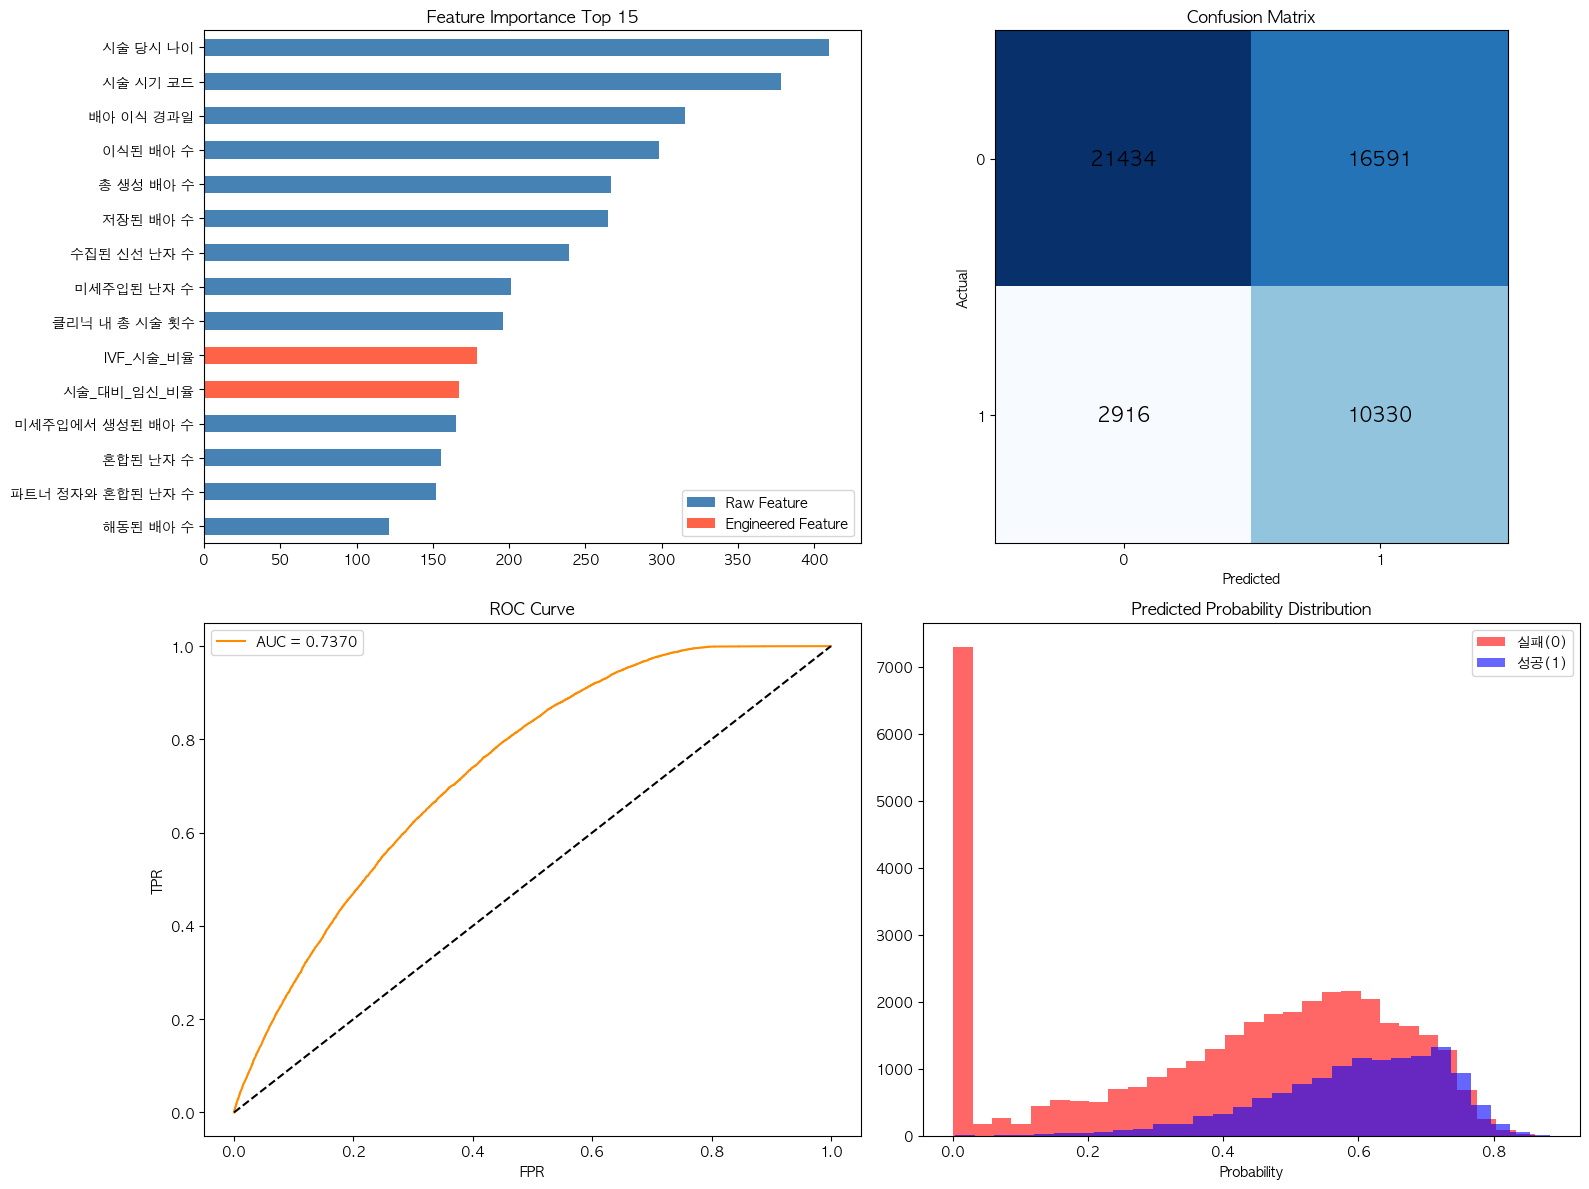

그래프 저장 완료: result_plots_exp020.png


In [ ]:
# # ════════════════════════════════════════════════════════════
# # 시각화
# # ════════════════════════════════════════════════════════════
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import roc_curve
# from matplotlib.patches import Patch

# engineered_features = [
#     "IVF_DI_시술_합산", "IVF_시술_비율",
#     "IVF_DI_임신_합산", "IVF_임신_비율",
#     "IVF_DI_출산_합산", "IVF_출산_비율",
#     "시술_대비_임신_비율", "불임_원인_개수", "배아_사용_조합",
#     "임신시도_결측여부", "이전_임신_여부", "이전_출산_여부",
#     "전체_임신_성공률", "난자_배아_전환율", "고령_여부", "첫_시술_여부",
#     "난자 채취 경과일_결측여부", "난자 혼합 경과일_결측여부", "배아 이식 경과일_결측여부",
#     # exp020 신규
#     "배아_이식_경과일_구간", "조기_이식_여부",
#     "채취_이식_경과일_차이", "혼합_이식_경과일_차이",
# ]

# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # 1) Feature Importance Top 15
# top15  = feat_imp.nlargest(15)
# colors = ['tomato' if f in engineered_features else 'steelblue' for f in top15.index]
# top15.plot(kind='barh', ax=axes[0, 0], color=colors)
# axes[0, 0].set_title('Feature Importance Top 15')
# axes[0, 0].invert_yaxis()
# axes[0, 0].legend(handles=[
#     Patch(facecolor='steelblue', label='Raw Feature'),
#     Patch(facecolor='tomato',    label='Engineered Feature'),
# ], loc='lower right')

# # 2) Confusion Matrix
# cm = confusion_matrix(y_val, val_pred)
# axes[0, 1].imshow(cm, cmap='Blues')
# axes[0, 1].set_title('Confusion Matrix')
# for i in range(2):
#     for j in range(2):
#         axes[0, 1].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
# axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')
# axes[0, 1].set_xticks([0, 1]);      axes[0, 1].set_yticks([0, 1])

# # 3) ROC Curve
# fpr, tpr, _ = roc_curve(y_val, val_proba)
# axes[1, 0].plot(fpr, tpr, label=f'AUC = {val_auc:.4f}', color='darkorange')
# axes[1, 0].plot([0, 1], [0, 1], 'k--')
# axes[1, 0].set_title('ROC Curve')
# axes[1, 0].set_xlabel('FPR'); axes[1, 0].set_ylabel('TPR')
# axes[1, 0].legend()

# # 4) 예측 확률 분포
# axes[1, 1].hist(val_proba[y_val == 0], bins=30, alpha=0.6, label='실패(0)', color='red')
# axes[1, 1].hist(val_proba[y_val == 1], bins=30, alpha=0.6, label='성공(1)', color='blue')
# axes[1, 1].set_title('Predicted Probability Distribution')
# axes[1, 1].set_xlabel('Probability'); axes[1, 1].legend()

# plt.tight_layout()
# plt.savefig('result_plots_exp020.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("그래프 저장 완료: result_plots_exp020.png")

In [ ]:
# # ════════════════════════════════════════════════════════════
# # catboost 확인
# # ════════════════════════════════════════════════════════════

# from catboost import CatBoostClassifier

# # CatBoost 베이스라인
# cat_params = {
#     "iterations":        500,
#     "learning_rate":     0.05,
#     "depth":             6,
#     "scale_pos_weight":  scale_pos_weight,
#     "random_seed":       42,
#     "verbose":           0,
#     "eval_metric":       "AUC",
#     "thread_count":      -1,
# }

# cat_model = CatBoostClassifier(**cat_params)
# cat_model.fit(X_train, y_train)

# cat_auc = roc_auc_score(y_val, cat_model.predict_proba(X_val)[:, 1])
# print(f"CatBoost Val AUC: {cat_auc:.4f}")

# val_pred  = cat_model.predict(X_val)
# val_proba = cat_model.predict_proba(X_val)[:, 1]

# print("\n[Classification Report]")
# print(classification_report(y_val, val_pred))
# print("\n[Confusion Matrix]")
# print(confusion_matrix(y_val, val_pred))

# feat_imp = pd.Series(cat_model.get_feature_importance(),
#                         index=X_train.columns)
# print("\n[Feature Importance Top 15]")
# print(feat_imp.nlargest(15))


CatBoost Val AUC: 0.7371

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.39      0.78      0.52     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.65     51271


[Confusion Matrix]
[[21682 16343]
 [ 2969 10277]]

[Feature Importance Top 15]
이식된 배아 수          46.175748
배아 이식 경과일_결측여부     9.531800
시술 당시 나이           6.192206
저장된 배아 수           5.559751
난자 채취 경과일_결측여부     4.377518
총 생성 배아 수          4.270691
배란 유도 유형           4.045979
수집된 신선 난자 수        2.490515
배아 생성 주요 이유        1.352864
시술 유형              1.259496
정자 출처              1.233601
배아 이식 경과일          0.943815
특정 시술 유형           0.865536
시술 시기 코드           0.814669
난자 기증자 나이          0.603991
dtype: float64


In [ ]:
# from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
# # ════════════════════════════════════════════════════════════
# # Optuna 가중치 앙상블 (LGB + CAT + XGB)
# # ════════════════════════════════════════════════════════════
# from xgboost import XGBClassifier
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # ── XGB 학습 (아직 없으면) ──
# xgb_params = {
#     "n_estimators":     500,
#     "learning_rate":    0.05,
#     "max_depth":        6,
#     "min_child_weight": 1,
#     "subsample":        0.8,
#     "colsample_bytree": 0.8,
#     "scale_pos_weight": scale_pos_weight,
#     "random_state":     42,
#     "n_jobs":           -1,
#     "verbosity":        0,
#     "eval_metric":      "auc",
# }
# xgb_model = XGBClassifier(**xgb_params)
# xgb_model.fit(X_train, y_train)

# # ── 각 모델 Val 확률 ──
# lgb_proba = check_model.predict_proba(X_val)[:, 1]   # 위 셀에서 학습된 LGB
# cat_proba = cat_model.predict_proba(X_val)[:, 1]     # 위 셀에서 학습된 CAT
# xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

# lgb_auc = roc_auc_score(y_val, lgb_proba)
# cat_auc = roc_auc_score(y_val, cat_proba)
# xgb_auc = roc_auc_score(y_val, xgb_proba)

# print(f"LGB Val AUC: {lgb_auc:.4f}")
# print(f"CAT Val AUC: {cat_auc:.4f}")
# print(f"XGB Val AUC: {xgb_auc:.4f}")


LGB Val AUC: 0.7370
CAT Val AUC: 0.7371
XGB Val AUC: 0.7352


In [ ]:
# # ── Optuna 가중치 최적화 ──
# def objective(trial):
#     w_lgb = trial.suggest_float("w_lgb", 0.0, 1.0)
#     w_cat = trial.suggest_float("w_cat", 0.0, 1.0)
#     w_xgb = trial.suggest_float("w_xgb", 0.0, 1.0)
#     total = w_lgb + w_cat + w_xgb + 1e-8
#     ensemble = (lgb_proba * w_lgb + cat_proba * w_cat + xgb_proba * w_xgb) / total
#     return roc_auc_score(y_val, ensemble)

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=200, show_progress_bar=True)

# # ── 최적 가중치 정규화 ──
# w = study.best_params
# total = w["w_lgb"] + w["w_cat"] + w["w_xgb"]
# w_lgb = w["w_lgb"] / total
# w_cat = w["w_cat"] / total
# w_xgb = w["w_xgb"] / total

# print(f"\nBest Val AUC:  {study.best_value:.4f}")
# print(f"최적 가중치 — LGB: {w_lgb:.3f} | CAT: {w_cat:.3f} | XGB: {w_xgb:.3f}")


  0%|          | 0/200 [00:00<?, ?it/s]


Best Val AUC:  0.7373
최적 가중치 — LGB: 0.412 | CAT: 0.573 | XGB: 0.015


In [ ]:
# # ── Val 최종 앙상블 성능 ──
# ensemble_val = lgb_proba * w_lgb + cat_proba * w_cat + xgb_proba * w_xgb
# ensemble_auc = roc_auc_score(y_val, ensemble_val)
# ensemble_pred = (ensemble_val >= 0.5).astype(int)

# print(f"\n[앙상블 Val AUC]: {ensemble_auc:.4f}")
# print("\n[Classification Report]")
# print(classification_report(y_val, ensemble_pred))
# print("\n[Confusion Matrix]")
# print(confusion_matrix(y_val, ensemble_pred))


[앙상블 Val AUC]: 0.7373

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.38      0.78      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271


[Confusion Matrix]
[[21558 16467]
 [ 2947 10299]]


* 윤재님 파일 다운받아서 그대로 재현했을때 [앙상블 Val AUC]: 0.7374 (LB 점수: 0.7412775224) 확보됨 
이것을 베이스라인으로 할 것임

1. 검증 방법:
train_test_split (test_size=0.2, stratify=y)

2. 사용 피처 수:
X_train.shape[1] (85개)

3. threshold:
0.5 (기본값, 튜닝 없음)

실험 계속. : feature engineering

In [ ]:
# feat_imp = pd.DataFrame({
#     "feature": X_train.columns,
#     "importance": check_model.feature_importances_
# }).sort_values("importance", ascending=False)

# print(feat_imp.head(20))

                  feature  importance
1                시술 당시 나이         410
0                시술 시기 코드         378
61              배아 이식 경과일         315
40               이식된 배아 수         298
37              총 생성 배아 수         267
42               저장된 배아 수         265
46            수집된 신선 난자 수         239
38             미세주입된 난자 수         201
28          클리닉 내 총 시술 횟수         196
79              IVF_시술_비율         179
84            시술_대비_임신_비율         167
39        미세주입에서 생성된 배아 수         165
48               혼합된 난자 수         155
49       파트너 정자와 혼합된 난자 수         152
44               해동된 배아 수         121
4                특정 시술 유형         120
17          불임 원인 - 남성 요인         107
53              난자 기증자 나이         103
2   임신 시도 또는 마지막 임신 경과 연수          96
29              IVF 시술 횟수          96
